In [19]:
import pyreadr
import numpy as np
import torch
from scipy.spatial.distance import cdist, pdist

from src.gmm import GMM
from src.flowgem import sample_flowgem

import numpy as np
import matplotlib.pyplot as plt

Load dataset.

In [12]:
datasets = ["parkinsons", "allergens", "concrete", "windspeed", "forest", "housing", "stock", "pumadyn32nm", "scm20d", "scm1d"]
#methods = ["flowgem", "mice", "gain", "hyperimpute", "miri", "bayes", "missdiff", "knewimp"]

In [99]:
datasets[1]

'allergens'

In [100]:
Xstar_df = pyreadr.read_r(f"datasets/split_test/test.{datasets[1]}.RDS")[None]
X_miss_df = pyreadr.read_r(f"datasets/split_amputed/mar.{datasets[1]}.RDS")[None]

Energy distance.

In [101]:
def energy_distance(X, Y, scale):
    if scale:
        X_np = np.array(X)
        Y_np = np.array(Y)
        center = np.nanmean(X_np, axis=0)
        scl = np.nanstd(X_np, axis=0, ddof=1)

        X = (X_np - center) / scl

        # Scale imputed data using original data's mean and std
        Y = (Y_np - center) / scl

    XY = cdist(X, Y)
    XX = cdist(X, X)
    YY = cdist(Y, Y)
    return (2 * XY.mean() - XX.mean() - YY.mean()) * X.shape[0] / 2

def energy_distance_faster(X, Y, scale):
    if torch.max(torch.abs(X)).item() > 1e100 and torch.max(torch.abs(Y)).item() < 1e100:
        return torch.inf
    if scale:
        X_np = np.array(X)
        Y_np = np.array(Y)
        center = np.nanmean(X_np, axis=0)
        scl = np.nanstd(X_np, axis=0, ddof=1)

        X = (X_np - center) / scl

        # Scale imputed data using original data's mean and std
        Y = (Y_np - center) / scl

    n = X.shape[0]
    xx_mean = pdist(X).sum() * 2 / (n * n)   # divide by n^2 to match cdist mean
    yy_mean = pdist(Y).sum() * 2 / (n * n)   # same for Y
    xy_mean = cdist(X, Y).mean()

    return (2 * xy_mean - xx_mean - yy_mean) * n / 2

def energy_distance_fixed_X(X, XX_mean, Y):
    XY_mean = cdist(X, Y).mean()
    n = len(Y)
    YY_mean = pdist(Y).mean() * (n - 1) / n
    return 2 * XY_mean - XX_mean - YY_mean

Prepare the data.

In [102]:
Xm = torch.tensor(X_miss_df.values, dtype=torch.float64)
X = torch.nan_to_num(Xm, nan=0.0) # input to GMM

Xstar = torch.tensor(Xstar_df.values)

M_np = (X_miss_df.notna()).astype(int).values
M = torch.tensor(M_np, dtype=torch.float64)

In [103]:
cov_type = 'uni_diag'
n_k = 100
start = 10
step = 2
n_mc = 500
n_samples = X.shape[0]

gmm = GMM(X, M, cov_type)
mu, sigma, pi, kk, q, loglik, aic, bic = gmm.iterEM(n_k, start, step, n_mc, n_samples)

0 12.00 -119454.78 240205.56 243490.29
1 14.00 -118246.79 237989.58 241781.21
2 16.00 -117397.12 236490.25 240788.78
3 18.00 -116947.09 235790.19 240595.62
4 20.00 -116482.71 235061.42 240373.76
5 22.00 -116198.64 234693.28 240512.52
6 24.00 -115885.58 234267.16 240593.30
7 26.00 -115518.34 233732.69 240565.73
8 28.00 -115195.53 233287.06 240627.01
9 30.00 -114740.50 232577.00 240423.85
10 32.00 -114652.28 232600.56 240954.31
11 34.00 -114590.34 232676.67 241537.32
12 36.00 -114545.99 232787.98 242155.54
13 38.00 -114513.27 232922.53 242796.99
14 40.00 -114489.39 233074.78 243456.14
15 42.00 -114474.45 233244.89 244133.15
16 44.00 -114458.27 233412.53 244807.70
17 46.00 -114396.88 233489.75 245391.82
18 48.00 -114190.86 233277.72 245686.69
19 50.00 -113905.08 232906.16 245822.03
20 52.00 -113718.70 232733.41 246156.18
21 54.00 -113337.52 232171.05 246100.72
22 56.00 -113299.52 232295.03 246731.61
23 58.00 -113249.11 232394.22 247337.70
24 60.00 -113226.23 232548.45 247998.84
25 62.00 -

In [104]:
mu.shape

torch.Size([54, 49])

In [105]:
energy_distance_gmm = [energy_distance_faster(Xstar, gmm.sample_gmm(mu, sigma, pi, X.shape[0]), scale=False) for _ in range(500)]

In [106]:
energy_distance_gmm_scaled = [energy_distance_faster(Xstar, gmm.sample_gmm(mu, sigma, pi, X.shape[0]), scale=True) for _ in range(500)]

/var/folders/mv/wxrc6hsj1f5_jnvh03d4d14c0000gn/T/ipykernel_96897/1622218340.py:22: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_np = np.array(X)
/var/folders/mv/wxrc6hsj1f5_jnvh03d4d14c0000gn/T/ipykernel_96897/1622218340.py:23: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  Y_np = np.array(Y)


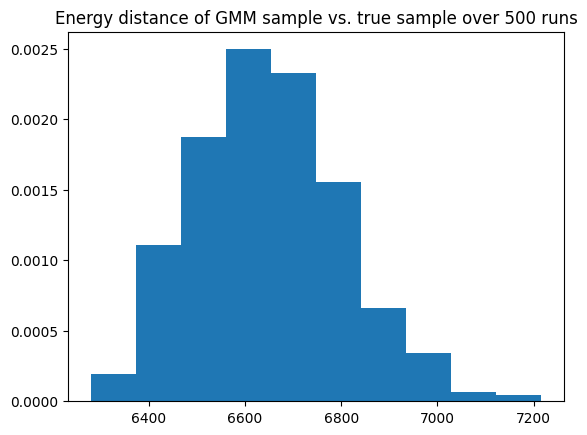

In [107]:
plt.hist(energy_distance_gmm, density=True)
plt.title('Energy distance of GMM sample vs. true sample over 500 runs')
plt.show()

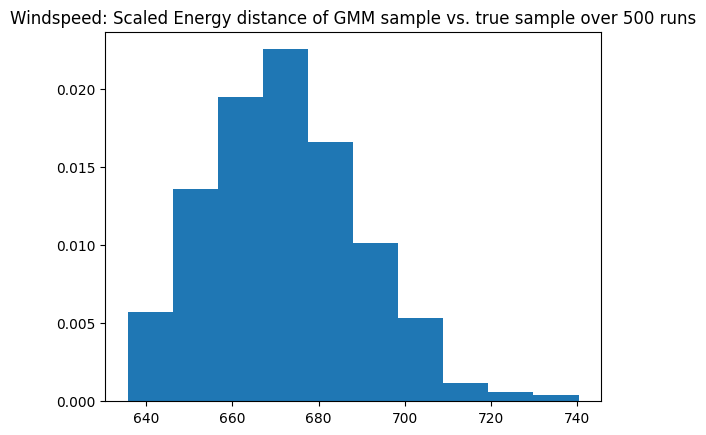

In [108]:
plt.hist(energy_distance_gmm_scaled, density=True)
plt.title('Windspeed: Scaled Energy distance of GMM sample vs. true sample over 500 runs')
plt.show()

In [ ]:
# Xhat_FG = sample_flowgem(X, X, M)

heuristic sigma: 18.06441326409088


WGF iterations:   1%|          | 10/1000 [00:00<00:12, 78.00it/s]

Step size eta is halved to 0.005 since mean grad has increased.
Step size eta is halved to 0.0025 since mean grad has increased.
Step size eta is halved to 0.00125 since mean grad has increased.
Stopped early after 11 iterations since mean grad 0.0001 is below grad_tol=0.01.


In [ ]:
# energy_distance_faster(Xstar, Xhat_FG[-1], scale=False)

np.float64(7383.763010830448)

In [ ]:
# energy_distance_faster(Xstar, Xhat_FG[-1], scale=True)

/var/folders/mv/wxrc6hsj1f5_jnvh03d4d14c0000gn/T/ipykernel_96897/1622218340.py:22: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X_np = np.array(X)


np.float64(204997.64705205715)